# Diabetes Prediction — Logistic Regression

**Goal:** Predict whether a patient has **diabetes** (binary: 0/1) from demographic and health features — gender, age, hypertension, heart disease, smoking history, BMI, HbA1c level, and blood glucose level — using Logistic Regression.

**Dataset:** `diabetes_prediction_dataset.csv` — 100,000 patient records, 9 columns (2 categorical, 6 numeric/binary, 1 target).

## 1. Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 2. Load & Clean Data

In [16]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df.head()

Shape: (100000, 9)

Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 3854


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [17]:
# Remove duplicate records
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

df.info()

Shape after removing duplicates: (96146, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


**Insight:** No missing values, but **3,854 duplicate rows** were found and removed (100,000 → 96,146). The dataset is otherwise clean and well-typed.

In [18]:
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
categorical_cols = ["gender", "smoking_history", "heart_disease", "hypertension"]

df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


## 3. Exploratory Data Analysis

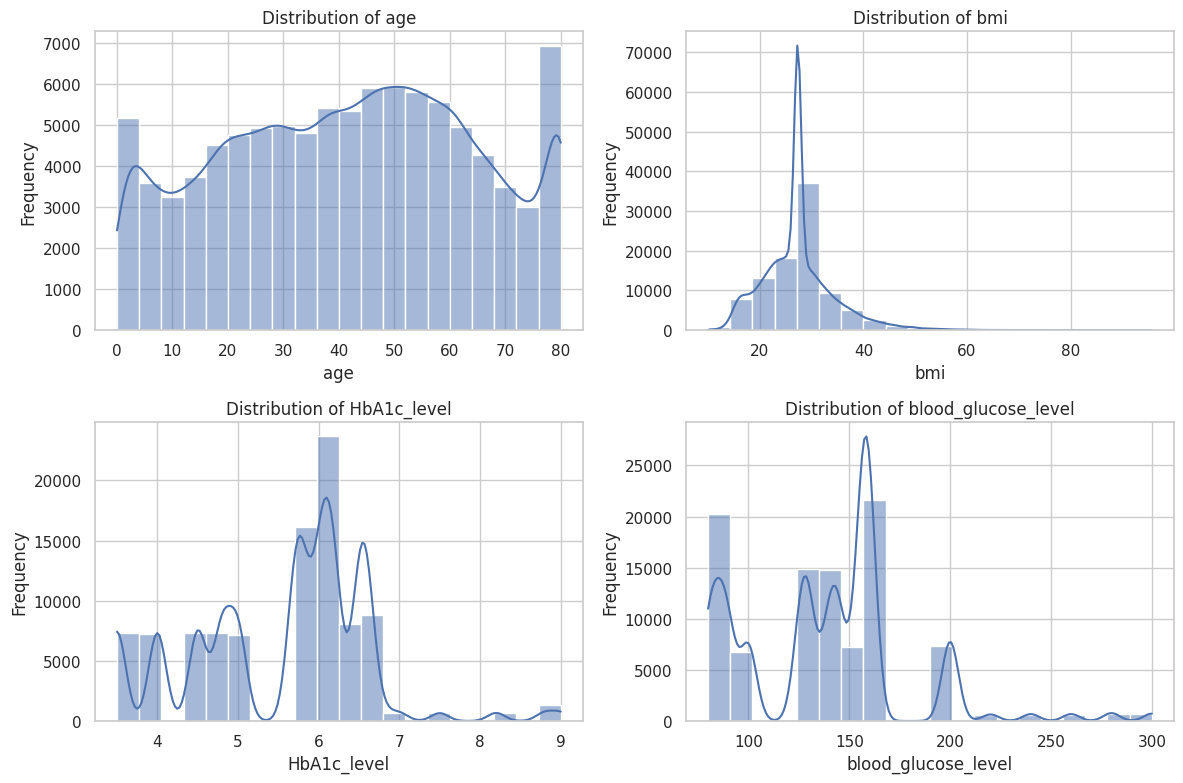

In [19]:
# Distribution of numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

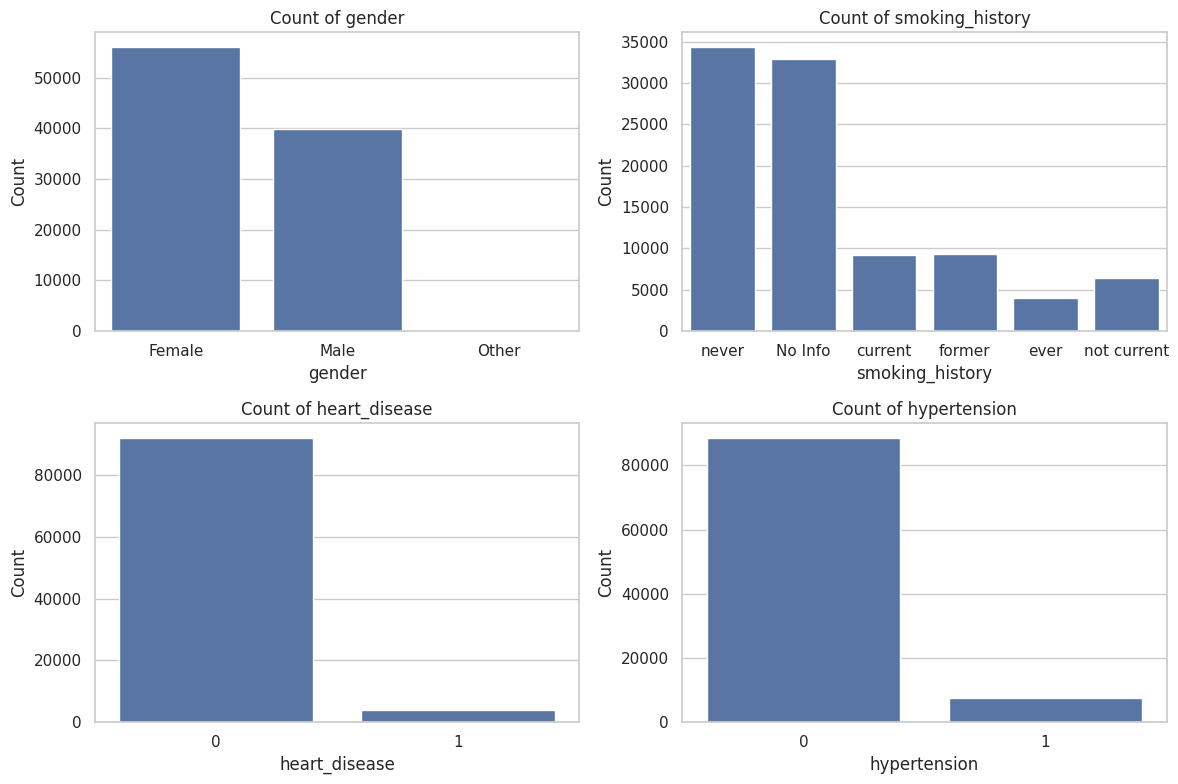

In [20]:
# Count of categorical features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

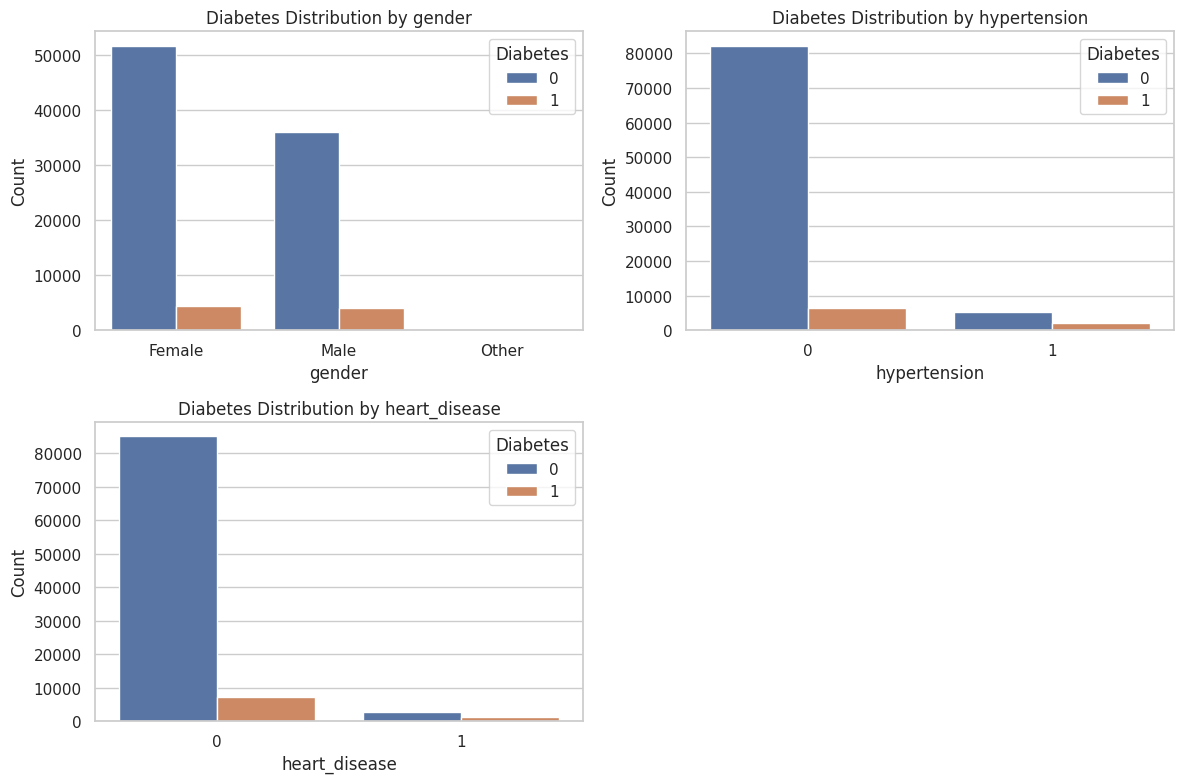

In [21]:
# Diabetes distribution grouped by gender, hypertension, heart disease
grouped_cols = ["gender", "hypertension", "heart_disease"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(grouped_cols):
    sns.countplot(data=df, x=col, hue="diabetes", ax=axes[i])
    axes[i].set_title(f"Diabetes Distribution by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Diabetes")

fig.delaxes(axes[3])
plt.tight_layout()
plt.show()

**Insight:** Diabetes is more common among patients with **hypertension** and **heart disease**, hinting these will be useful predictors. Gender shows only a mild difference in diabetes rates.

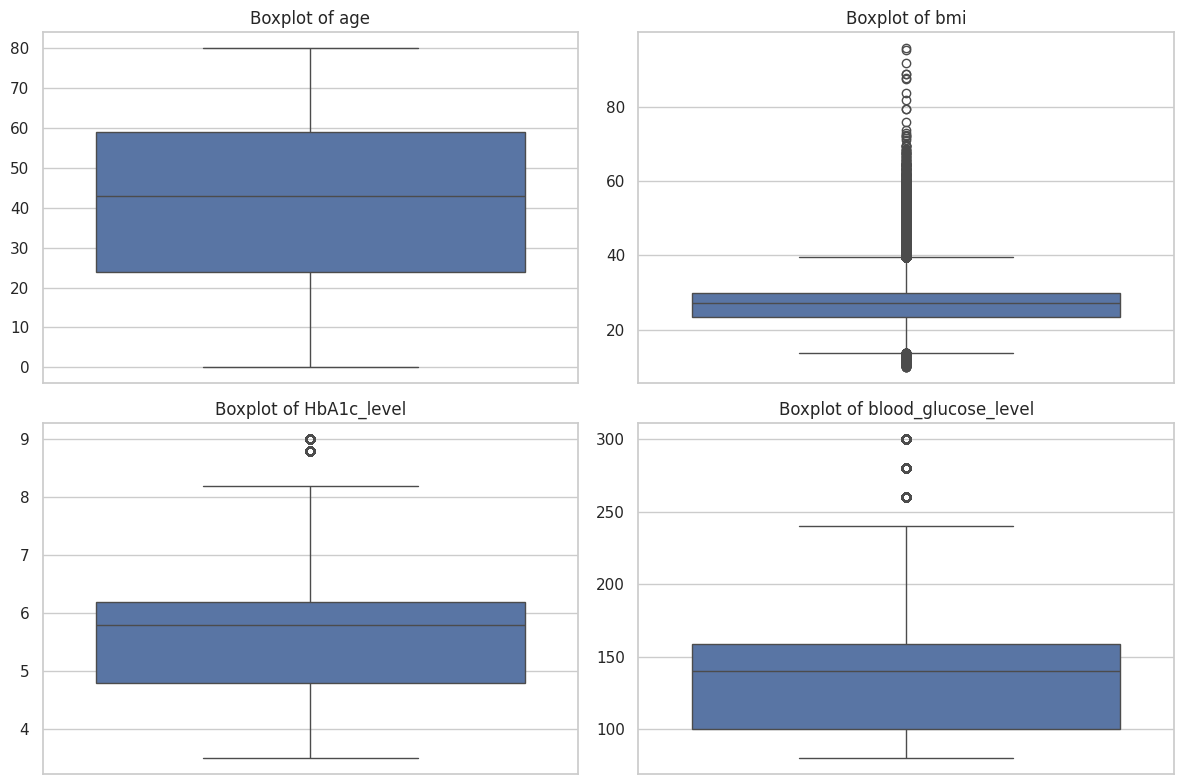

In [22]:
# Boxplots to check for outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

Shape after outlier handling: (96146, 9)


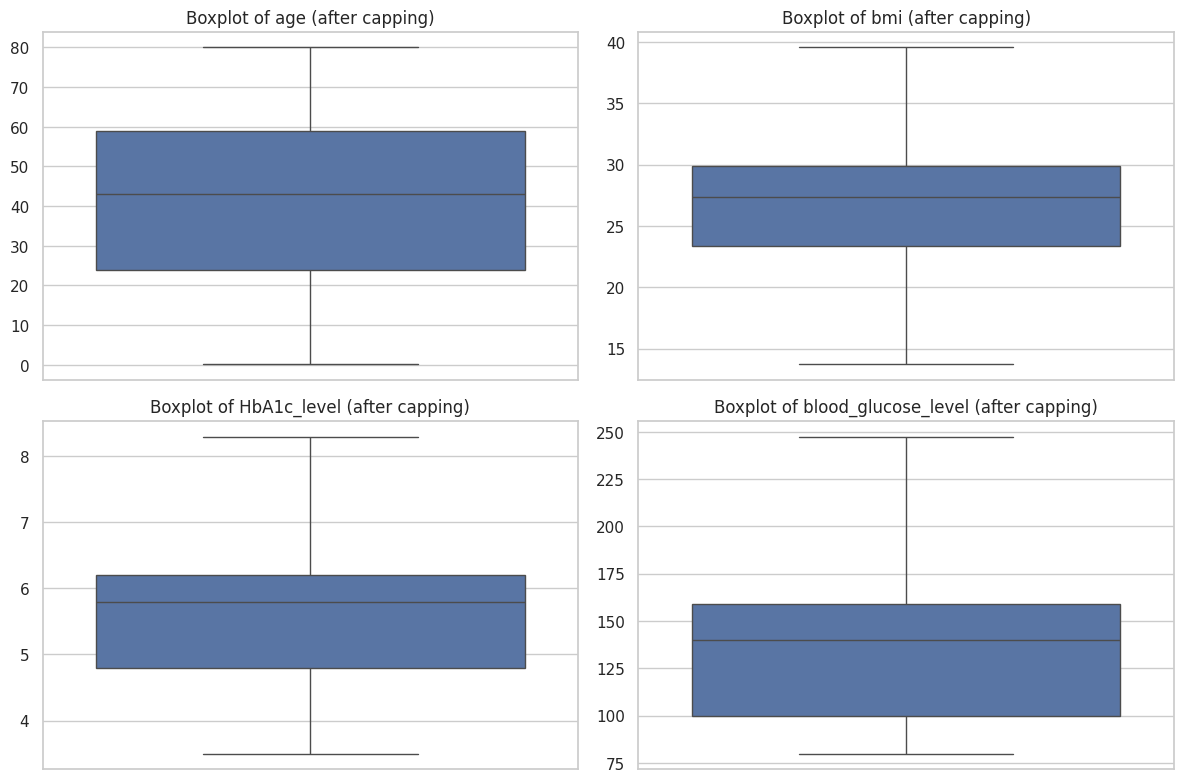

In [23]:
# Cap outliers using the IQR method
selected_cols = ["bmi", "HbA1c_level", "blood_glucose_level"]

for col in selected_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Shape after outlier handling:", df.shape)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} (after capping)")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

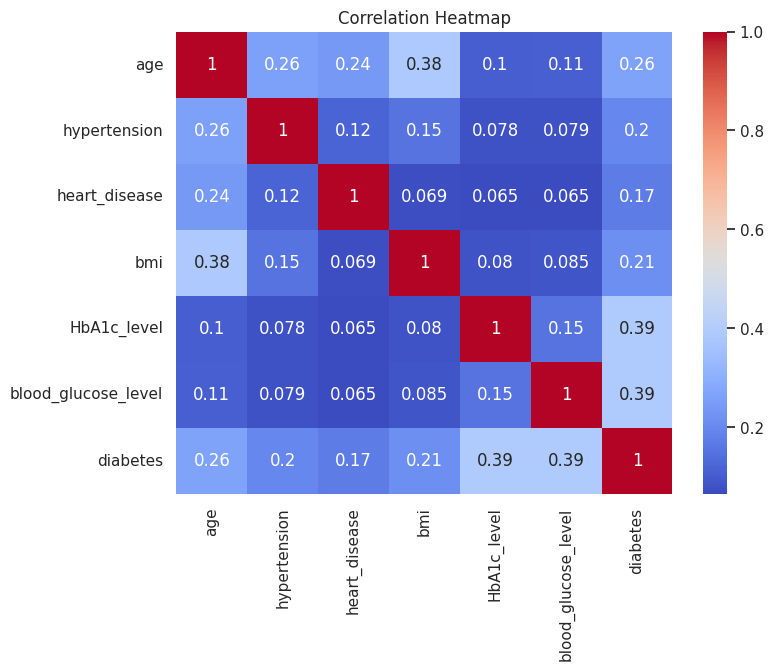

In [24]:
# Correlation between numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
#distribution of classes
df['diabetes'].value_counts()

,count
diabetes,
0,87664
1,8482


**Insight:** Outliers in `bmi`, `HbA1c_level`, and `blood_glucose_level` were **capped (not removed)** using the IQR method, preserving all 96,146 rows. `HbA1c_level` and `blood_glucose_level` show the strongest correlation with `diabetes`. The Target variable is imbalanced because one class has many more samples and another class have very few samples

## 4. Preprocessing

Split the data (stratified, to keep class balance), one-hot encode categorical columns, then scale numeric features — all fit on train and applied to test to avoid data leakage.

In [26]:
categorical_cols = ["gender", "smoking_history"]


def split_data(df, target="diabetes", test_size=0.2, random_state=42):
    X = df.drop(columns=[target])
    y = df[target]
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


def encode_features(X_train, X_test, categorical_cols):
    encoder = OneHotEncoder(sparse_output=False, drop="first")
    encoder.fit(X_train[categorical_cols])

    def _encode(X):
        encoded = pd.DataFrame(
            encoder.transform(X[categorical_cols]),
            columns=encoder.get_feature_names_out(categorical_cols),
            index=X.index,
        )
        return pd.concat([X.drop(columns=categorical_cols), encoded], axis=1)

    return _encode(X_train), _encode(X_test), encoder


def scale_features(X_train, X_test):
    scaler = StandardScaler()
    scaler.fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)


X_train, X_test, y_train, y_test = split_data(df)
X_train_encoded, X_test_encoded, encoder = encode_features(X_train, X_test, categorical_cols)
X_train_scaled, X_test_scaled = scale_features(X_train_encoded, X_test_encoded)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (76916, 13)
Test shape: (19230, 13)


## 5. Train the Logistic Regression Model

In [27]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

train_score = logistic_model.score(X_train_scaled, y_train)
test_score = logistic_model.score(X_test_scaled, y_test)

print(f"Train Score: {train_score:.4f}")
print(f"Test Score:  {test_score:.4f}")

Train Score: 0.9576
Test Score:  0.9583


## 6. Model Evaluation

In [28]:
def evaluate_model(y_test, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    }
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return metrics


evaluate_model(y_test, y_pred)

Accuracy: 0.9583
Precision: 0.8570
Recall: 0.6327
F1 Score: 0.7280

Confusion Matrix:
 [[17355   179]
 [  623  1073]]


{'Accuracy': 0.958294331773271,
 'Precision': 0.8570287539936102,
 'Recall': 0.6326650943396226,
 'F1 Score': 0.7279511533242876}

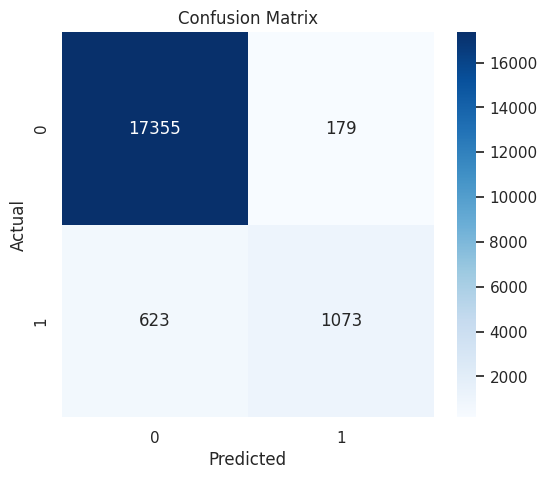

In [29]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

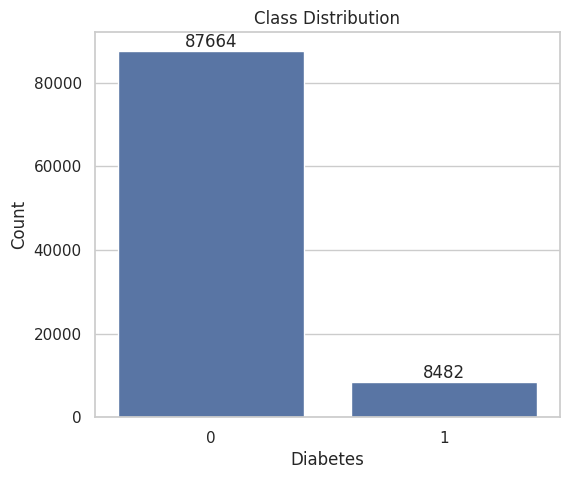

In [30]:
# Class distribution (imbalance check)
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="diabetes", data=df)
ax.bar_label(ax.containers[0])
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

**Insight:** The baseline model reaches **95.8% accuracy**, but the dataset is **imbalanced** (far fewer diabetic cases). Recall on the diabetic class is only **0.63** — meaning ~37% of actual diabetic patients are missed, which matters more than raw accuracy in a medical context.

## 7. Handling Class Imbalance

In [31]:
# Re-weight the minority (diabetic) class to reduce false negatives
logistic_model = LogisticRegression(class_weight={0: 1, 1: 1.8}, max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

train_score = logistic_model.score(X_train_scaled, y_train)
test_score = logistic_model.score(X_test_scaled, y_test)

print(f"Train Score: {train_score:.4f}")
print(f"Test Score:  {test_score:.4f}")

evaluate_model(y_test, y_pred)

Train Score: 0.9531
Test Score:  0.9528
Accuracy: 0.9528
Precision: 0.7527
Recall: 0.6928
F1 Score: 0.7215

Confusion Matrix:
 [[17148   386]
 [  521  1175]]


{'Accuracy': 0.9528341133645346,
 'Precision': 0.7527226137091608,
 'Recall': 0.6928066037735849,
 'F1 Score': 0.7215228738102548}

**Insight:** Weighting the diabetic class (`1.8x`) trades a small accuracy drop (95.8% → 95.3%) for a **better recall (0.63 → 0.69)** — catching more true diabetic cases at the cost of slightly more false positives. This is a worthwhile trade-off for a health screening use case.

## 8. Summary

- 96,146 clean records after removing duplicates; outliers capped, not dropped.
- `HbA1c_level`, `blood_glucose_level`, `hypertension`, and `heart_disease` are the strongest signals for diabetes.
- Baseline Logistic Regression: **95.8% accuracy**, but low recall (0.63) due to class imbalance.
- Class-weighted model improves recall to **0.69** with only a small accuracy trade-off — a better fit when missing a diabetic case is costlier than a false alarm.